# Dataset Cuaca Tiga Kota Jawa Timur

**Nama:** Muhammad Iqbal Fadel  
**NIM:** 202310370311268  
**Mata Kuliah:** Machine Learning / C  
**Institusi:** Universitas Muhammadiyah Malang  
**Tahun:** 2026  

---

## Deskripsi Dataset

Dataset ini berisi data cuaca harian dari tiga kota di Jawa Timur, yaitu Kota Malang, Kota Batu, dan Kota Surabaya, untuk rentang waktu 2023 sampai 2024. Data dikumpulkan menggunakan Open-Meteo Historical Weather API yang bersumber dari ERA5-Land, sebuah dataset reanalysis milik European Centre for Medium-Range Weather Forecasts (ECMWF).

Dataset ini dirancang untuk keperluan tugas machine learning dengan task klasifikasi kondisi cuaca harian (Cerah, Berawan, atau Hujan) berdasarkan parameter meteorologi seperti suhu, kelembaban, curah hujan, kecepatan angin, dan lama penyinaran matahari.

## Sumber Data

- **Platform:** Open-Meteo Historical Weather API  
- **Basis data:** ERA5-Land (ECMWF)  
- **Lisensi:** Creative Commons Attribution 4.0 (CC BY 4.0)

## Bagian 1 — Persiapan

Bagian ini mencakup proses instalasi dan impor library yang dibutuhkan
untuk pengambilan dan pengolahan data cuaca. Library utama yang digunakan
adalah openmeteo-requests untuk mengakses Open-Meteo API, dan pandas
untuk mengolah data dalam bentuk tabel.

In [15]:
# Install library yang dibutuhkan
!pip install openmeteo-requests requests-cache retry-requests --quiet

In [16]:
# Import library
import openmeteo_requests
import requests_cache
import pandas as pd
from retry_requests import retry

## Bagian 2 — Konfigurasi

Bagian ini mendefinisikan parameter utama yang digunakan selama proses
pengambilan data, meliputi koordinat geografis ketiga kota dan rentang
waktu pengambilan data.

Setiap kota direpresentasikan menggunakan koordinat geografis dalam
format desimal, yaitu latitude (lat) yang menunjukkan posisi utara-selatan
dan longitude (lon) yang menunjukkan posisi timur-barat. Koordinat yang
digunakan merupakan titik pusat administratif masing-masing kota berdasarkan
data wilayah administrasi dari Badan Pusat Statistik (BPS).

Nilai latitude negatif menunjukkan posisi di belahan bumi selatan, sesuai
dengan letak Indonesia yang berada di bawah garis khatulistiwa.

Rincian koordinat yang digunakan:

- Kota Malang: -7.9797 LS, 112.6304 BT  
- Kota Batu: -7.8703 LS, 112.5267 BT  
- Kota Surabaya: -7.2575 LS, 112.7521 BT

In [17]:
# Konfigurasi kota dan rentang waktu
KOTA = [
    {"nama": "Malang",   "lat": -7.9797, "lon": 112.6304},
    {"nama": "Batu",     "lat": -7.8703, "lon": 112.5267},
    {"nama": "Surabaya", "lat": -7.2575, "lon": 112.7521},
]

TANGGAL_MULAI = "2023-01-01"
TANGGAL_AKHIR = "2024-12-31"

## Bagian 3 — Pengambilan Data

Data cuaca diambil menggunakan Open-Meteo Historical Weather API dengan
basis data ERA5-Land dari ECMWF. Proses pengambilan dilakukan secara
berulang untuk masing-masing kota berdasarkan koordinat yang telah
didefinisikan pada Bagian 2.

Parameter cuaca yang diambil meliputi suhu minimum, suhu maksimum, suhu
rata-rata, curah hujan harian, kelembaban rata-rata, kecepatan angin
rata-rata, dan lama penyinaran matahari. Seluruh data memiliki resolusi
harian dan diperoleh dalam format yang sudah terstruktur.

In [18]:
# Setup koneksi ke Open-Meteo API dengan caching dan retry otomatis
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
om = openmeteo_requests.Client(session=retry_session)

# Fungsi untuk mengambil data satu kota
def ambil_data_kota(nama, lat, lon):
    params = {
        "latitude": lat,
        "longitude": lon,
        "daily": [
            "temperature_2m_min",
            "temperature_2m_max",
            "temperature_2m_mean",
            "precipitation_sum",
            "relative_humidity_2m_mean",
            "wind_speed_10m_mean",
            "sunshine_duration"
        ],
        "start_date": TANGGAL_MULAI,
        "end_date": TANGGAL_AKHIR,
        "timezone": "Asia/Jakarta"
    }

    response = om.weather_api("https://archive-api.open-meteo.com/v1/archive", params=params)
    r = response[0]
    daily = r.Daily()

    df = pd.DataFrame({
        "tanggal"         : pd.date_range(
                                start=pd.to_datetime(daily.Time(), unit="s", utc=True),
                                end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
                                freq=pd.Timedelta(seconds=daily.Interval()),
                                inclusive="left"
                            ).tz_convert("Asia/Jakarta").strftime("%Y-%m-%d"),
        "kota"            : nama,
        "suhu_min"        : daily.Variables(0).ValuesAsNumpy(),
        "suhu_max"        : daily.Variables(1).ValuesAsNumpy(),
        "suhu_rata"       : daily.Variables(2).ValuesAsNumpy(),
        "curah_hujan"     : daily.Variables(3).ValuesAsNumpy(),
        "kelembaban"      : daily.Variables(4).ValuesAsNumpy(),
        "kecepatan_angin" : daily.Variables(5).ValuesAsNumpy(),
        "lama_penyinaran" : daily.Variables(6).ValuesAsNumpy() / 3600
    })

    return df

# Ambil data untuk setiap kota dan gabungkan
list_df = []
for kota in KOTA:
    print(f"Mengambil data: {kota['nama']}...")
    df_kota = ambil_data_kota(kota["nama"], kota["lat"], kota["lon"])
    list_df.append(df_kota)
    print(f"Selesai: {len(df_kota)} baris")

df_gabung = pd.concat(list_df, ignore_index=True)
print(f"\nTotal data terkumpul: {len(df_gabung)} baris")

Mengambil data: Malang...
Selesai: 731 baris
Mengambil data: Batu...
Selesai: 731 baris
Mengambil data: Surabaya...
Selesai: 731 baris

Total data terkumpul: 2193 baris


## Bagian 4 — Pelabelan Data

Kolom kondisi_cuaca ditambahkan sebagai label utama untuk keperluan
klasifikasi. Label diturunkan secara otomatis dari nilai curah_hujan
harian menggunakan aturan berikut:

- Cerah   : curah_hujan = 0 mm
- Berawan : curah_hujan lebih dari 0 mm dan kurang dari atau sama dengan 5 mm
- Hujan   : curah_hujan lebih dari 5 mm

Kolom lama_penyinaran yang sebelumnya dalam satuan detik telah dikonversi
ke satuan jam pada proses pengambilan data.

In [19]:
# Tambahkan kolom kondisi_cuaca berdasarkan curah hujan
def tentukan_kondisi(curah_hujan):
    if curah_hujan == 0:
        return "Cerah"
    elif curah_hujan <= 5:
        return "Berawan"
    else:
        return "Hujan"

df_gabung["kondisi_cuaca"] = df_gabung["curah_hujan"].apply(tentukan_kondisi)

# Tampilkan preview dataset
print("Preview 5 baris pertama:")
print(df_gabung.head())
print(f"\nUkuran dataset: {df_gabung.shape[0]} baris, {df_gabung.shape[1]} kolom")
print(f"\nKolom dataset: {list(df_gabung.columns)}")

Preview 5 baris pertama:
      tanggal    kota   suhu_min   suhu_max  suhu_rata  curah_hujan  \
0  2023-01-01  Malang  22.376001  27.876001  24.607252     2.500000   
1  2023-01-02  Malang  21.776001  28.276001  24.253084     1.400000   
2  2023-01-03  Malang  20.726000  28.926001  24.159332     3.400000   
3  2023-01-04  Malang  21.176001  28.226000  23.780167     6.700000   
4  2023-01-05  Malang  21.176001  27.226000  23.684336     8.300001   

   kelembaban  kecepatan_angin  lama_penyinaran kondisi_cuaca  
0   85.531403         3.388300         6.828130       Berawan  
1   86.635262         4.274699         7.066754       Berawan  
2   86.084984         4.941360        10.546527       Berawan  
3   88.189362         5.082366         8.620545         Hujan  
4   89.556831         5.760620        10.529516         Hujan  

Ukuran dataset: 2193 baris, 10 kolom

Kolom dataset: ['tanggal', 'kota', 'suhu_min', 'suhu_max', 'suhu_rata', 'curah_hujan', 'kelembaban', 'kecepatan_angin', 'lama

## Bagian 5 — Pembersihan Data

Proses pembersihan dilakukan untuk memastikan kualitas dataset sebelum
digunakan dalam pemodelan machine learning. Tahapan yang dilakukan meliputi
pengecekan duplikasi data, pengecekan nilai kosong (missing values),
pengecekan distribusi label kondisi_cuaca, serta tinjauan statistik
deskriptif untuk mendeteksi nilai yang tidak wajar.

In [20]:
print("=" * 50)
print("1. PENGECEKAN DUPLIKASI")
print("=" * 50)
duplikat = df_gabung.duplicated().sum()
print(f"Jumlah baris duplikat: {duplikat}")

print("\n" + "=" * 50)
print("2. PENGECEKAN MISSING VALUES")
print("=" * 50)
print(df_gabung.isnull().sum())

print("\n" + "=" * 50)
print("3. DISTRIBUSI LABEL KONDISI CUACA")
print("=" * 50)
print(df_gabung["kondisi_cuaca"].value_counts())
print(f"\nPersentase:")
print(df_gabung["kondisi_cuaca"].value_counts(normalize=True).mul(100).round(2).astype(str) + " %")

print("\n" + "=" * 50)
print("4. STATISTIK DESKRIPTIF")
print("=" * 50)
print(df_gabung.describe().round(2))

1. PENGECEKAN DUPLIKASI
Jumlah baris duplikat: 0

2. PENGECEKAN MISSING VALUES
tanggal            0
kota               0
suhu_min           0
suhu_max           0
suhu_rata          0
curah_hujan        0
kelembaban         0
kecepatan_angin    0
lama_penyinaran    0
kondisi_cuaca      0
dtype: int64

3. DISTRIBUSI LABEL KONDISI CUACA
kondisi_cuaca
Berawan    930
Hujan      711
Cerah      552
Name: count, dtype: int64

Persentase:
kondisi_cuaca
Berawan    42.41 %
Hujan      32.42 %
Cerah      25.17 %
Name: proportion, dtype: object

4. STATISTIK DESKRIPTIF
       suhu_min  suhu_max  suhu_rata  curah_hujan  kelembaban  \
count   2193.00   2193.00    2193.00      2193.00     2193.00   
mean      21.41     28.55      24.55         6.46       81.36   
std        2.66      2.96       2.84        11.03        8.92   
min       14.50     21.90      18.75         0.00       49.75   
25%       19.35     26.05      22.08         0.00       75.39   
50%       21.33     28.38      24.15         1.

### Kesimpulan Pembersihan Data

Berdasarkan hasil pengecekan, dataset dinyatakan bersih dan siap digunakan
untuk pemodelan. Tidak ditemukan baris duplikat maupun nilai kosong pada
seluruh 10 kolom dataset.

Distribusi label kondisi_cuaca menunjukkan komposisi Berawan sebesar 42,41%,
Hujan 32,42%, dan Cerah 25,17%. Ketimpangan distribusi ini bersifat wajar
dan mencerminkan karakteristik iklim tropis Jawa Timur yang didominasi
oleh hari berawan dan hujan, sehingga tidak diperlukan penyeimbangan data
pada tahap ini.

Tinjauan statistik deskriptif tidak menunjukkan nilai yang tidak wajar.
Curah hujan maksimum sebesar 83,80 mm tergolong hujan lebat dan merupakan
nilai yang valid untuk wilayah Jawa Timur. Seluruh kolom numerik berada
dalam rentang yang sesuai secara meteorologi.

## Bagian 6 — Eksplorasi Awal

Eksplorasi awal dilakukan untuk mendapatkan gambaran umum tentang
karakteristik dataset sebelum digunakan dalam pemodelan. Bagian ini
menampilkan informasi struktur data, contoh baris per kota, dan
ringkasan distribusi setiap kolom numerik per kota.

In [21]:
print("=" * 50)
print("1. INFORMASI STRUKTUR DATASET")
print("=" * 50)
df_gabung.info()

print("\n" + "=" * 50)
print("2. CONTOH DATA PER KOTA")
print("=" * 50)
for nama_kota in df_gabung["kota"].unique():
    print(f"\n>>> {nama_kota}")
    print(df_gabung[df_gabung["kota"] == nama_kota].head(3).to_string(index=False))

print("\n" + "=" * 50)
print("3. RATA-RATA SUHU DAN CURAH HUJAN PER KOTA")
print("=" * 50)
print(df_gabung.groupby("kota")[["suhu_min", "suhu_max", "suhu_rata", "curah_hujan"]].mean().round(2))

print("\n" + "=" * 50)
print("4. DISTRIBUSI LABEL PER KOTA")
print("=" * 50)
print(df_gabung.groupby("kota")["kondisi_cuaca"].value_counts())

1. INFORMASI STRUKTUR DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2193 entries, 0 to 2192
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tanggal          2193 non-null   object 
 1   kota             2193 non-null   object 
 2   suhu_min         2193 non-null   float32
 3   suhu_max         2193 non-null   float32
 4   suhu_rata        2193 non-null   float32
 5   curah_hujan      2193 non-null   float32
 6   kelembaban       2193 non-null   float32
 7   kecepatan_angin  2193 non-null   float32
 8   lama_penyinaran  2193 non-null   float32
 9   kondisi_cuaca    2193 non-null   object 
dtypes: float32(7), object(3)
memory usage: 111.5+ KB

2. CONTOH DATA PER KOTA

>>> Malang
   tanggal   kota  suhu_min  suhu_max  suhu_rata  curah_hujan  kelembaban  kecepatan_angin  lama_penyinaran kondisi_cuaca
2023-01-01 Malang 22.376001 27.876001  24.607252          2.5   85.531403         3.388300        

### Kesimpulan Eksplorasi Awal

Eksplorasi awal mengungkapkan perbedaan karakteristik cuaca yang jelas
di antara ketiga kota, yang mencerminkan perbedaan kondisi geografis
masing-masing.

Kota Batu mencatat suhu rata-rata terendah (21,56°C) dan curah hujan
tertinggi (7,72 mm/hari), konsisten dengan posisinya di dataran tinggi
pegunungan. Kota Surabaya mencatat suhu rata-rata tertinggi (27,99°C)
dan curah hujan terendah (4,74 mm/hari), sesuai dengan karakteristik
kota pesisir dataran rendah. Kota Malang berada di antara keduanya
dengan suhu rata-rata 24,11°C dan curah hujan 6,91 mm/hari.

Pola distribusi label per kota juga konsisten dengan kondisi geografis
tersebut. Kota Batu dan Kota Malang didominasi label Berawan, sementara
Kota Surabaya didominasi label Cerah. Kecepatan angin di Surabaya
tercatat jauh lebih tinggi dibanding dua kota lainnya, yang disebabkan
oleh posisinya di wilayah pesisir yang lebih terbuka terhadap angin laut.

Perbedaan karakteristik antar kota ini justru memperkaya variasi dataset
dan diharapkan dapat membantu model machine learning dalam mempelajari
pola klasifikasi kondisi cuaca secara lebih baik.

## Bagian 7 — Ekspor Dataset

Dataset yang telah melalui proses pengambilan, pelabelan, dan eksplorasi
awal disimpan dalam format CSV (Comma-Separated Values). Format ini dipilih
karena bersifat universal, ringan, dan kompatibel dengan berbagai platform
analisis data maupun machine learning.

Dataset disimpan ke Google Drive secara otomatis sesuai dengan direktori
aktif notebook, dan dapat diunduh langsung melalui cell di bawah ini.

In [22]:
# Simpan dataset ke file CSV
nama_file = "dataset_cuaca_tiga_kota_jatim.csv"
df_gabung.to_csv(nama_file, index=False)

print(f"Dataset berhasil disimpan: {nama_file}")
print(f"Ukuran akhir dataset: {df_gabung.shape[0]} baris, {df_gabung.shape[1]} kolom")

# Unduh file ke komputer
from google.colab import files
files.download(nama_file)

Dataset berhasil disimpan: dataset_cuaca_tiga_kota_jatim.csv
Ukuran akhir dataset: 2193 baris, 10 kolom


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Bagian 8 — Visualisasi Data

Visualisasi dilakukan untuk mempermudah pemahaman terhadap karakteristik
dan pola yang terdapat dalam dataset. Bagian ini menampilkan empat grafik
utama, yaitu distribusi kondisi cuaca per kota, tren suhu rata-rata bulanan,
perbandingan distribusi suhu antar kota, dan korelasi antar fitur numerik.

In [23]:
import os
os.makedirs("images", exist_ok=True)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

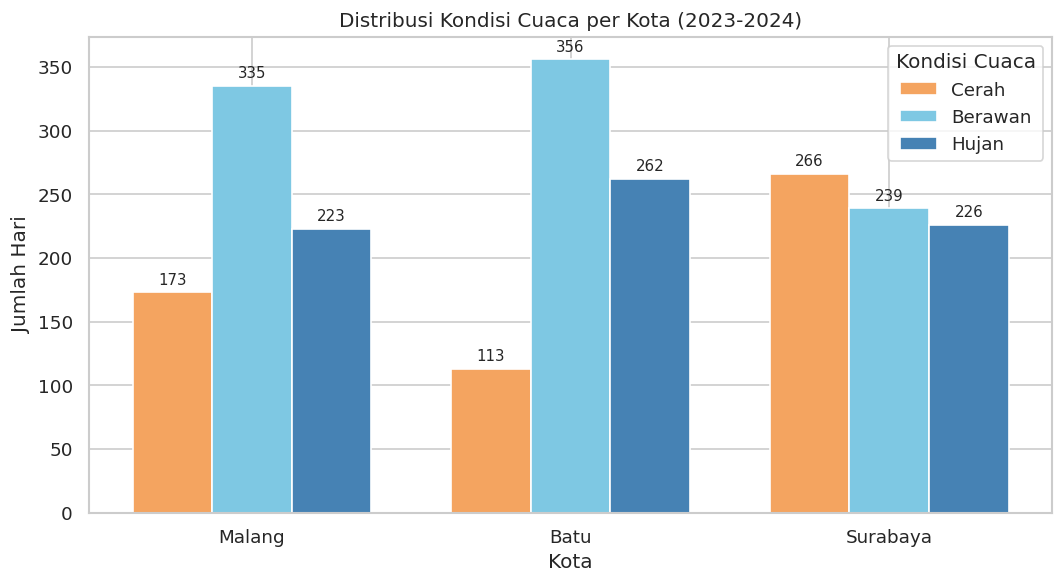

In [25]:
# Grafik 1 — Distribusi kondisi cuaca per kota
fig, ax = plt.subplots(figsize=(9, 5))

urutan_kota = ["Malang", "Batu", "Surabaya"]
urutan_label = ["Cerah", "Berawan", "Hujan"]
warna = ["#F4A460", "#7EC8E3", "#4682B4"]

data_plot = df_gabung.groupby(["kota", "kondisi_cuaca"]).size().reset_index(name="jumlah")

x = range(len(urutan_kota))
lebar = 0.25

for i, (label, warna_bar) in enumerate(zip(urutan_label, warna)):
    nilai = [
        data_plot[(data_plot["kota"] == kota) & (data_plot["kondisi_cuaca"] == label)]["jumlah"].values[0]
        for kota in urutan_kota
    ]
    offset = [xi + i * lebar for xi in x]
    bars = ax.bar(offset, nilai, width=lebar, label=label, color=warna_bar, edgecolor="white")
    for bar, val in zip(bars, nilai):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4,
                str(val), ha="center", va="bottom", fontsize=9)

ax.set_xticks([xi + lebar for xi in x])
ax.set_xticklabels(urutan_kota)
ax.set_xlabel("Kota")
ax.set_ylabel("Jumlah Hari")
ax.set_title("Distribusi Kondisi Cuaca per Kota (2023-2024)")
ax.legend(title="Kondisi Cuaca")
plt.tight_layout()
plt.savefig("images/grafik_1_distribusi_kondisi_cuaca.png", bbox_inches="tight")
plt.show()

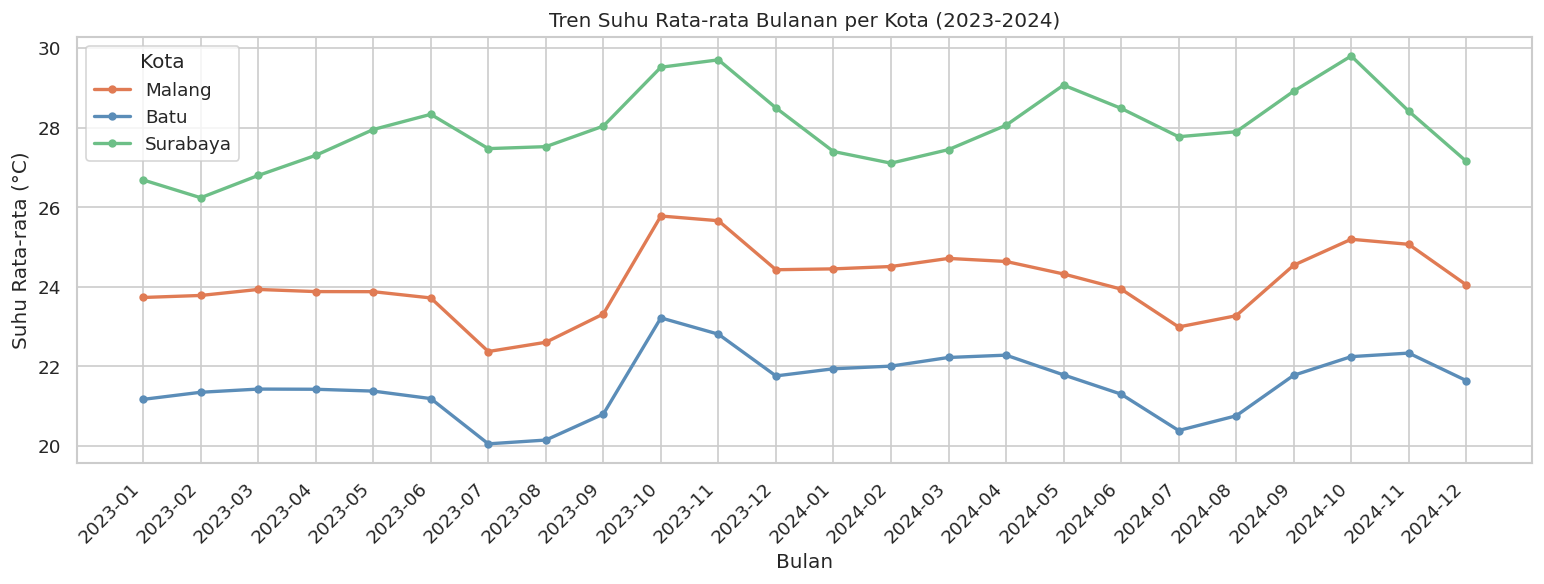

In [26]:
# Grafik 2 — Tren suhu rata-rata bulanan per kota
df_gabung["bulan"] = pd.to_datetime(df_gabung["tanggal"]).dt.to_period("M").astype(str)

tren_suhu = df_gabung.groupby(["bulan", "kota"])["suhu_rata"].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))

warna_kota = {"Malang": "#E07B54", "Batu": "#5B8DB8", "Surabaya": "#6DBF87"}

for kota, warna in warna_kota.items():
    data_kota = tren_suhu[tren_suhu["kota"] == kota]
    ax.plot(data_kota["bulan"], data_kota["suhu_rata"],
            marker="o", label=kota, color=warna, linewidth=2, markersize=4)

ax.set_xlabel("Bulan")
ax.set_ylabel("Suhu Rata-rata (°C)")
ax.set_title("Tren Suhu Rata-rata Bulanan per Kota (2023-2024)")
ax.legend(title="Kota")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("images/grafik_2_tren_suhu_bulanan.png", bbox_inches="tight")
plt.show()

/tmp/ipykernel_2805/3036222917.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=urutan_kota, patch_artist=True,


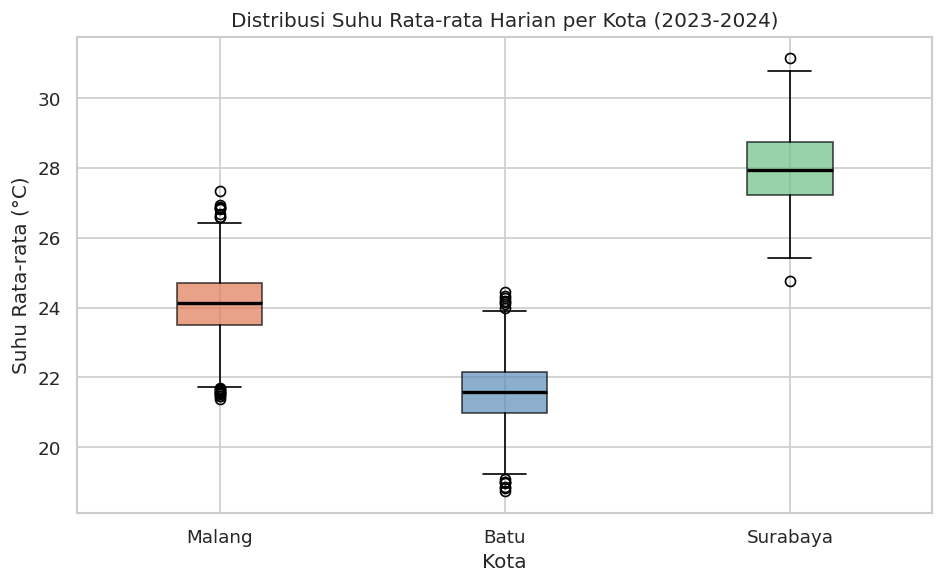

In [27]:
# Grafik 3 — Box plot distribusi suhu rata-rata per kota
fig, ax = plt.subplots(figsize=(8, 5))

warna_box = ["#E07B54", "#5B8DB8", "#6DBF87"]
urutan_kota = ["Malang", "Batu", "Surabaya"]

data_box = [df_gabung[df_gabung["kota"] == kota]["suhu_rata"].values for kota in urutan_kota]

bp = ax.boxplot(data_box, labels=urutan_kota, patch_artist=True,
                medianprops=dict(color="black", linewidth=2))

for patch, warna in zip(bp["boxes"], warna_box):
    patch.set_facecolor(warna)
    patch.set_alpha(0.7)

ax.set_xlabel("Kota")
ax.set_ylabel("Suhu Rata-rata (°C)")
ax.set_title("Distribusi Suhu Rata-rata Harian per Kota (2023-2024)")
plt.tight_layout()
plt.savefig("images/grafik_3_boxplot_suhu.png", bbox_inches="tight")
plt.show()

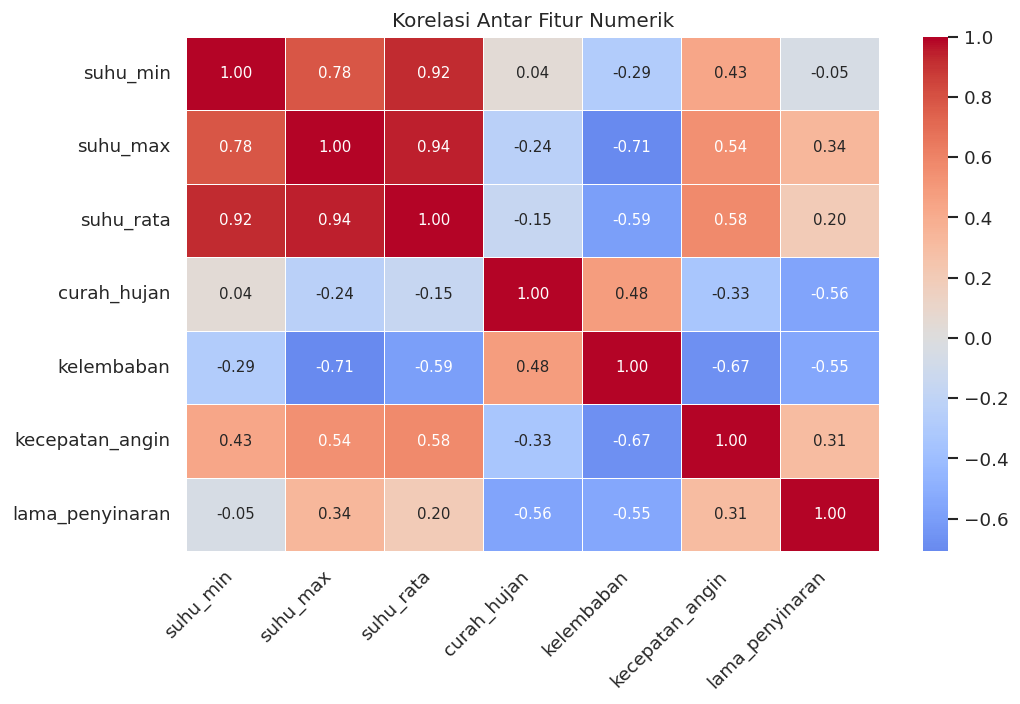

In [28]:
# Grafik 4 — Heatmap korelasi antar fitur numerik
fig, ax = plt.subplots(figsize=(9, 6))

kolom_numerik = ["suhu_min", "suhu_max", "suhu_rata",
                 "curah_hujan", "kelembaban",
                 "kecepatan_angin", "lama_penyinaran"]

korelasi = df_gabung[kolom_numerik].corr()

sns.heatmap(korelasi, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax,
            annot_kws={"size": 9})

ax.set_title("Korelasi Antar Fitur Numerik")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("images/grafik_4_heatmap_korelasi.png", bbox_inches="tight")
plt.show()

### Kesimpulan Visualisasi

Keempat grafik mengungkapkan pola yang konsisten dengan karakteristik
geografis masing-masing kota.

Grafik distribusi kondisi cuaca menunjukkan bahwa Kota Batu dan Kota
Malang didominasi hari Berawan, sementara Kota Surabaya memiliki proporsi
hari Cerah tertinggi di antara ketiganya. Grafik tren bulanan memperlihatkan
pola musiman yang serupa di ketiga kota, dengan suhu cenderung meningkat
pada pertengahan tahun (Juni sampai Oktober) yang bertepatan dengan musim
kemarau.

Box plot memperlihatkan bahwa Kota Surabaya memiliki sebaran suhu yang
lebih lebar dibanding Kota Malang dan Kota Batu, yang mencerminkan
variabilitas suhu yang lebih tinggi di kota pesisir. Nilai di luar
jangkauan (outlier) yang muncul bukan merupakan kesalahan data, melainkan
mencerminkan hari-hari dengan kondisi suhu ekstrem yang wajar terjadi
secara meteorologi.

Heatmap korelasi menunjukkan beberapa hubungan yang signifikan. Kelembaban
berkorelasi negatif kuat dengan suhu maksimum (-0.71), yang berarti hari
dengan suhu tinggi cenderung memiliki kelembaban rendah. Lama penyinaran
matahari berkorelasi negatif dengan curah hujan (-0.56) dan kelembaban
(-0.55), yang berarti hari dengan sinar matahari panjang cenderung lebih
kering. Pola-pola ini konsisten dengan dinamika iklim tropis dan mendukung
relevansi fitur-fitur yang dipilih untuk task klasifikasi kondisi cuaca.

In [29]:
# Unduh semua grafik sekaligus
import zipfile
from google.colab import files

with zipfile.ZipFile("images.zip", "w") as zipf:
    for nama_file in os.listdir("images"):
        zipf.write(f"images/{nama_file}", nama_file)

files.download("images.zip")
print("Semua grafik berhasil diunduh.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Semua grafik berhasil diunduh.


## Bagian 9 — Kamus Data

Kamus data (data dictionary) berisi penjelasan lengkap untuk setiap kolom
yang terdapat dalam dataset, meliputi nama kolom, tipe data, satuan, dan
deskripsi singkat.

| Kolom | Tipe | Satuan | Deskripsi |
|---|---|---|---|
| tanggal | object | - | Tanggal pengamatan dalam format YYYY-MM-DD |
| kota | object | - | Nama kota: Malang, Batu, atau Surabaya |
| suhu_min | float64 | °C | Suhu udara terendah yang tercatat dalam satu hari |
| suhu_max | float64 | °C | Suhu udara tertinggi yang tercatat dalam satu hari |
| suhu_rata | float64 | °C | Rata-rata suhu udara sepanjang hari |
| curah_hujan | float64 | mm | Total curah hujan yang tercatat dalam satu hari |
| kelembaban | float64 | % | Rata-rata kelembaban udara relatif sepanjang hari |
| kecepatan_angin | float64 | km/jam | Rata-rata kecepatan angin sepanjang hari |
| lama_penyinaran | float64 | jam | Durasi sinar matahari yang menyinari permukaan dalam satu hari |
| kondisi_cuaca | object | - | Label kondisi cuaca harian: Cerah, Berawan, atau Hujan |

## Bagian 10 — Keterbatasan Dataset

Beberapa keterbatasan yang perlu diperhatikan dalam penggunaan dataset ini:

1. Data yang digunakan merupakan data reanalysis dari ERA5-Land, bukan
hasil pengamatan langsung dari stasiun meteorologi. Meskipun reanalysis
telah divalidasi secara ilmiah dan digunakan luas dalam penelitian,
terdapat kemungkinan perbedaan kecil dengan kondisi cuaca aktual di
lapangan.

2. Cakupan dataset terbatas pada tiga kota yaitu Malang, Batu, dan
Surabaya. Hasil analisis dan model yang dibangun dari dataset ini tidak
dapat digeneralisasi secara langsung ke seluruh wilayah Jawa Timur.

3. Label kondisi_cuaca diturunkan secara otomatis dari nilai curah_hujan
menggunakan aturan sederhana. Pendekatan ini tidak mempertimbangkan
faktor lain seperti tutupan awan aktual atau jarak pandang, sehingga
terdapat kemungkinan ketidaksesuaian dengan kondisi cuaca yang dirasakan
secara langsung.

4. Dataset mencakup rentang waktu dua tahun (2023-2024), sehingga belum
cukup untuk analisis tren iklim jangka panjang. Penambahan rentang waktu
disarankan untuk keperluan analisis yang lebih mendalam.

## Daftar Referensi

Hersbach, H., Bell, B., Berrisford, P., Hirahara, S., Horanyi, A.,
Munoz-Sabater, J., Nicolas, J., Peubey, C., Radu, R., Schepers, D.,
Simmons, A., Soci, C., Abdalla, S., Abellan, X., Balsamo, G., Bechtold,
P., Biavati, G., Bidlot, J., Bonavita, M., ... Thepaut, J. (2020).
The ERA5 global reanalysis. Quarterly Journal of the Royal Meteorological
Society, 146(730), 1999-2049. https://doi.org/10.1002/qj.3803

Munoz-Sabater, J., Dutra, E., Agustí-Panareda, A., Albergel, C.,
Arduini, G., Balsamo, G., Boussetta, S., Choulga, M., Harrigan, S.,
Hersbach, H., Martens, B., Miralles, D. G., Piles, M., Rodríguez-Fernández,
N. J., Zsoter, E., Buontempo, C., & Thépaut, J. N. (2021). ERA5-Land:
A state-of-the-art global reanalysis dataset for land applications.
Earth System Science Data, 13(9), 4349-4383.
https://doi.org/10.5194/essd-13-4349-2021

Zippenfenig, P. (2023). Open-Meteo.com Weather API. Zenodo.
https://doi.org/10.5281/zenodo.7970649

Badan Pusat Statistik. (2024). Data wilayah administrasi kota
di Jawa Timur. Diakses dari https://www.bps.go.id